## 로지스틱 회귀와 성능평가

In [ ]:
# 데이터 불러오기
import numpy as np
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X, y = data.data, data.target

print("데이터 모양:", X.shape)
print("클래스 이름:", data.target_names)
print("클래스별 개수:", np.bincount(y))


데이터 모양: (569, 30)
클래스 이름: ['malignant' 'benign']
클래스별 개수: [212 357]


In [ ]:
# 나누고 표준화
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print("훈련:", X_train.shape, "/ 테스트:", X_test.shape)
print("훈련 클래스 비용:", np.bincount(y_train)/len(y_train))


훈련: (455, 30) / 테스트: (114, 30)
훈련 클래스 비용: [0.37362637 0.62637363]


### 시그모이드 로지스틱 회귀

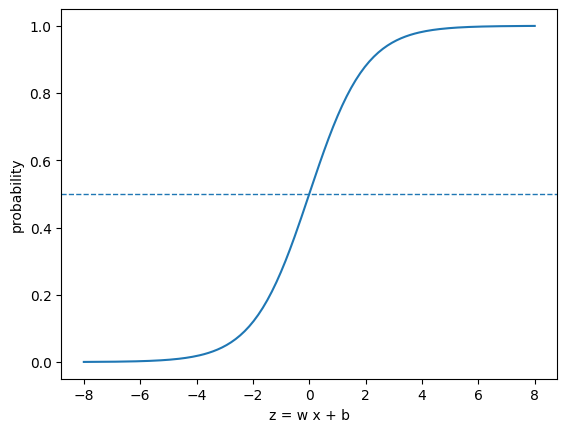

sigmoid(-4) = 0.018
sigmoid(0) = 0.5
sigmoid(4) = 0.982


In [ ]:
#시그모이드 그리기
import matplotlib.pyplot as plt
def sigmoid(z):
  return 1/(1+np.exp(-z))

z = np.linspace(-8, 8, 200)
plt.plot(z, sigmoid(z))
plt.axhline(0.5, linestyle="--", linewidth=1)
plt.xlabel("z = w x + b")
plt.ylabel("probability")
plt.show()

print("sigmoid(-4) =", round(sigmoid(-4), 4))
print("sigmoid(0) =", round(sigmoid(0), 4))
print("sigmoid(4) =", round(sigmoid(4), 4))

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
print("예측 앞 열 개:", y_pred[:10])
print("실제 앞 열 개:", y_test[:10])

예측 앞 열 개: [0 1 0 1 0 1 1 0 0 0]
실제 앞 열 개: [0 1 0 1 0 1 1 0 0 0]


In [ ]:
proba = model.predict_proba(X_test_s)[:, 1] #양성(정상) 확률

print("확률 앞 다섯 개:", np.round(proba[:5], 4))
print("가장 애매한 다섯 건:", np.round(np.sort(np.abs(proba - 0.5)) [:5], 4))
print("확률이 0.5 근처 (0.4~0.6)인 건수:", int(((proba > 0.4) & (proba < 0.6)).sum()))

확률 앞 다섯 개: [0.     1.     0.0064 0.5335 0.    ]
가장 애매한 다섯 건: [0.0335 0.037  0.0466 0.1213 0.1341]
확률이 0.5 근처 (0.4~0.6)인 건수: 3


In [ ]:
# 표준화 없이 학습
model_raw = LogisticRegression(max_iter=1000)
model_raw.fit(X_train, y_train) #원래 단위 그대로 학습

from sklearn.metrics import accuracy_score

print("표준화함 반복 횟수:", model.n_iter_[0],
"/ 정확도: ", round (accuracy_score(y_test, y_pred), 4))
print("표준화안함 반복 횟수:", model_raw.n_iter_[0],
"/ 정확도:", round(accuracy_score(y_test, model_raw.predict(X_test)), 4))

표준화함 반복 횟수: 19 / 정확도:  0.9825
표준화안함 반복 횟수: 1000 / 정확도: 0.9649


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [ ]:
# 혼동행렬 추출
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

tn, fp, fn, tp = cm.ravel()
print("TN(악성을 악성으로) =", tn)
print("FP(악성을 정상으로) =", fp)
print("FN(정상을 악성으로) =", fn)
print("TP(정상을 정상으로) =", tp)

[[41  1]
 [ 1 71]]
TN(악성을 악성으로) = 41
FP(악성을 정상으로) = 1
FN(정상을 악성으로) = 1
TP(정상을 정상으로) = 71
